RFM Customer Segmentation

RFM(Recency, Frequency, Monetary)

Recency: 
- How recently customer purchased
- Recent customer = active customer

Frequency: 
- How often customer purchases
- Frequent customer = loyal customer

Monetary: 
- How much money customer spends
- High monetary value = VIP customer

Businesses use RFM  for:

- customer segmentation
- loyalty programs
- churn prevention
- personalized marketing
- VIP identification

RFM shows:

- business understanding
- customer analytics
- clustering knowledge
- feature engineering
- segmentation skills

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [60]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [61]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [62]:
#Recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [63]:
#Creating RFM Table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

In [64]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [65]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,1658.40
12349.0,19,3,3678.69
12350.0,310,1,294.40


Customer ID  :  12346
- Recency = 326 ---> Customer last purchased 326 days ago.
- Frequency = 12 ---> Customer made 12 unique purchases.
- Monetary = 77556.46  ---> Customer spent a very large amount of money.


VIP / loyal customers
| Recency | Frequency | Monetary |
| ------- | --------- | -------- |
| LOW     | HIGH      | HIGH     |

Weak Customers
| Recency | Frequency | Monetary |
| ------- | --------- | -------- |
| HIGH    | LOW       | LOW      |



In [66]:
rfm.describe()

,Recency,Frequency,Monetary
count,5862.000000,5862.000000,5862.000000
mean,200.867793,6.257250,2916.816540
std,209.095351,12.810858,14337.149296
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,338.725000
50%,95.500000,3.000000,855.220000
75%,379.000000,7.000000,2237.032500
max,739.000000,379.000000,580987.040000


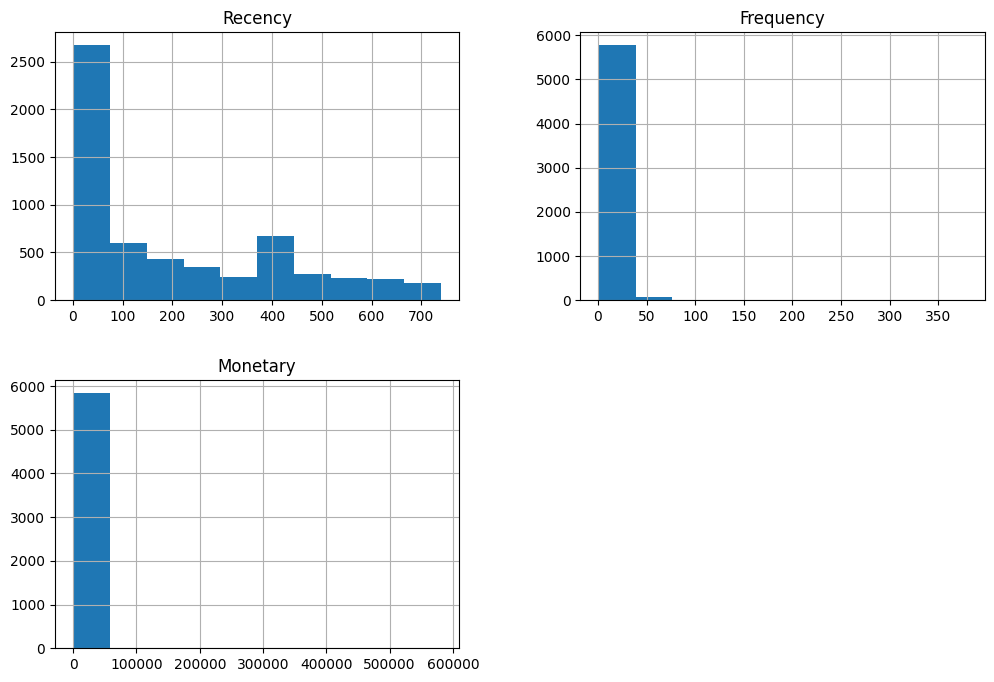

In [67]:
rfm.hist(figsize=(12,8))

plt.show()

Insight
- Recency, Frequency, and Monetary distributions are highly right-skewed.
- Most customers purchase infrequently and spend relatively low amounts.
- A small group of customers purchases very frequently and contributes exceptionally high revenue.
- The dataset contains clear high-value customer segments suitable for RFM analysis and customer segmentation.

#Log Transformation: 
- reduces skewness 
- compresses extreme values
- improves clustering quality


In [68]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])

rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])

rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,5.789960,2.564949,11.258774
12347.0,1.098612,2.197225,8.501578
12348.0,4.330733,1.791759,7.414211
12349.0,2.995732,1.386294,8.210584
12350.0,5.739793,0.693147,5.688330


Log transformation reduces the influence of extremely large values while preserving customer behavior patterns.

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [70]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

In [71]:
rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.858510,1.259721,3.220007
12347.0,-2.150283,0.804758,1.226553
12348.0,-0.077364,0.303101,0.440387
12349.0,-0.933566,-0.198557,1.016164
12350.0,0.826335,-1.056145,-0.807426


Elbow Method

In [72]:
from sklearn.cluster import KMeans

In [73]:
inertia = []

In [74]:
for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

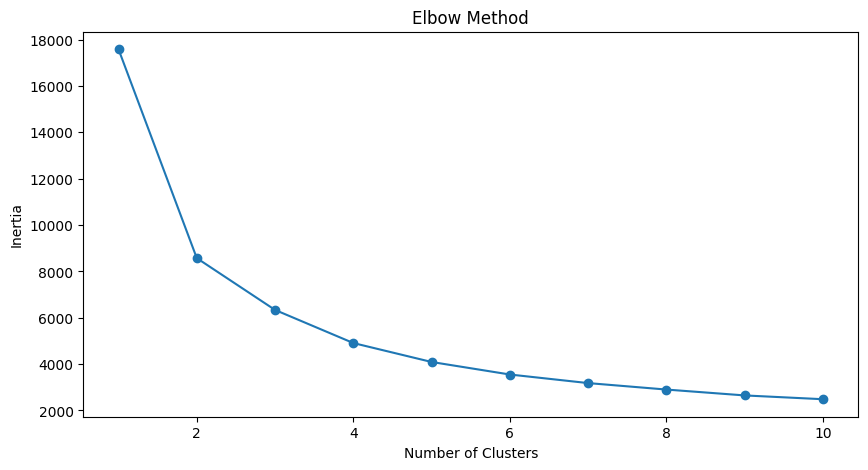

In [75]:
plt.figure(figsize=(10,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("../outputs/charts/rfm/rfm_elbow_method.png")

plt.show()

In [76]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

In [77]:
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [78]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,5
12348.0,75,5,1658.40,2
12349.0,19,3,3678.69,5
12350.0,310,1,294.40,0


In [79]:
rfm['Cluster'].value_counts()

Cluster
0    1480
4    1251
3    1039
2     936
5     703
1     453
Name: count, dtype: int64

In [80]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,432.387162,1.210135,243.021751
1,14.980132,32.662252,20738.851113
2,98.813034,9.327991,3967.919847
3,39.512993,2.157844,573.349338
4,310.716227,3.310152,1145.391026
5,12.118065,7.082504,2278.008110


In [81]:
segment_map = {
    0: "Lost Low-Value Customers",
    1: "VIP Champions",
    2: "Loyal High-Value Customers",
    3: "New / Occasional Customers",
    4: "At-Risk Regular Customers",
    5: "Active Potential Loyalists"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,2,Loyal High-Value Customers
12347.0,2,8,4921.53,5,Active Potential Loyalists
12348.0,75,5,1658.40,2,Loyal High-Value Customers
12349.0,19,3,3678.69,5,Active Potential Loyalists
12350.0,310,1,294.40,0,Lost Low-Value Customers


In [82]:
rfm.to_csv(
    "../outputs/rfm_customer_segments.csv"
)

print("RFM customer segments saved successfully!")

RFM customer segments saved successfully!


RFM Segmentation Insight

Six customer segments were created using K-Means clustering on Recency, Frequency, and Monetary features. VIP Champions showed the highest frequency and monetary value, while Lost Low-Value Customers had high recency, low frequency, and low spending. This segmentation enables targeted marketing, loyalty campaigns, and churn prevention strategies.

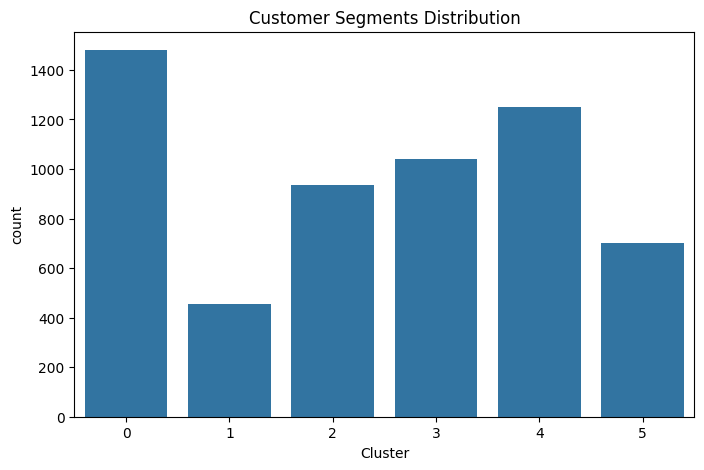

In [83]:
#Cluster Counts
plt.figure(figsize=(8,5))

sns.countplot(x='Cluster', data=rfm)

plt.title("Customer Segments Distribution")

plt.savefig("../outputs/charts/rfm/rfm_customer_segments.png")

plt.show()

Insight
- Cluster 0 contains the largest number of customers.
- Customer distribution is relatively balanced across clusters.
- The business serves multiple customer behavior groups with different purchasing patterns.

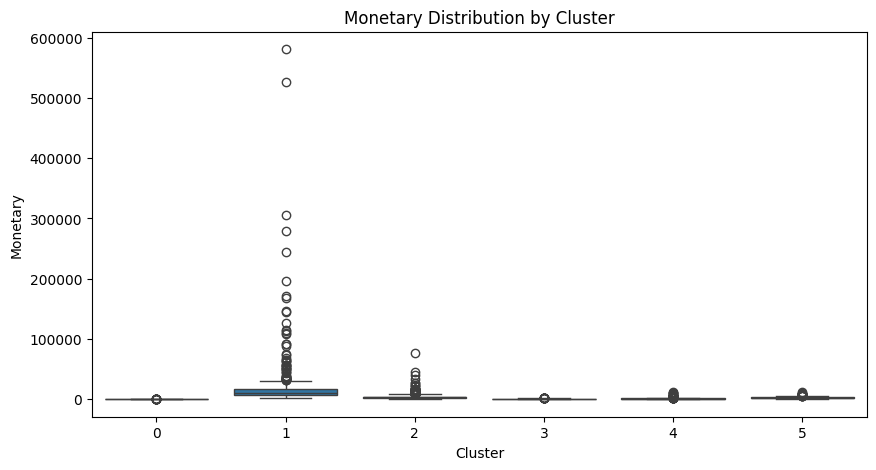

In [84]:
#Monetary by Cluster
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Cluster',
    y='Monetary',
    data=rfm
)

plt.title("Monetary Distribution by Cluster")

plt.savefig("../outputs/charts/rfm/rfm_monetary_by_cluster.png")

plt.show()

Insight
- Cluster 1 generates significantly higher revenue than all other clusters.
- VIP customers contribute disproportionately high monetary value.
- Cluster 0 and Cluster 3 contain low-spending customers.

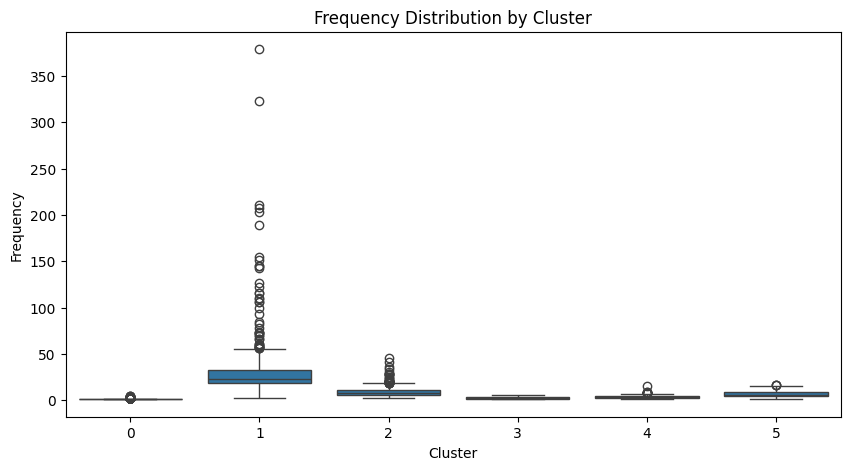

In [85]:
#Frequency by Cluster
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Cluster',
    y='Frequency',
    data=rfm
)

plt.title("Frequency Distribution by Cluster")

plt.savefig("../outputs/charts/rfm/rfm_frequency_by_cluster.png")

plt.show()

Insight
- Cluster 1 customers purchase much more frequently than other clusters.
- Cluster 0 customers have very low purchase frequency.
- Frequency differences clearly distinguish loyal and inactive customers.

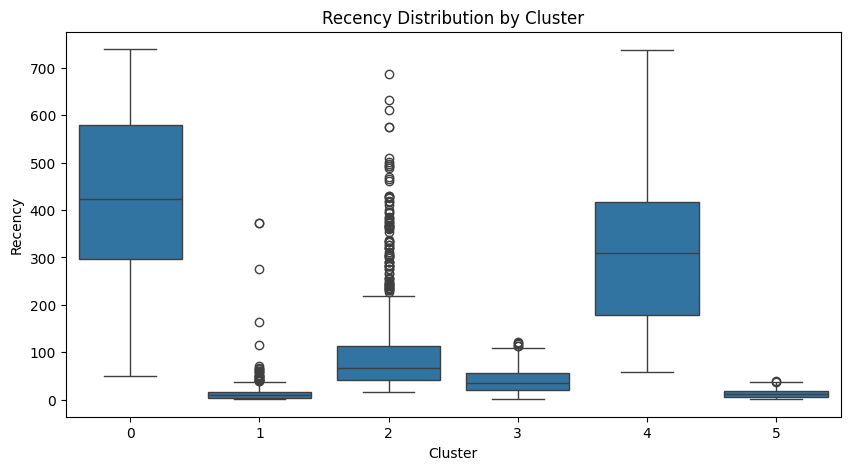

In [86]:
#Recency by Cluster
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Cluster',
    y='Recency',
    data=rfm
)

plt.title("Recency Distribution by Cluster")

plt.savefig("../outputs/charts/rfm/rfm_recency_by_cluster.png")

plt.show()

Insight
- Cluster 1 and Cluster 3 customers purchased recently, indicating active engagement.
- Cluster 0 customers have very high recency values, suggesting inactive or churn-risk behavior.
- Cluster 2 customers show moderate purchasing recency.